In [ ]:
# ==================================================
# CELL 1: INSTALL DEPENDENCIES
# ==================================================
!pip install dlib imutils

In [ ]:
# ==================================================
# CELL 2: IMPORT LIBRARIES
# ==================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
# ==================================================
# CELL 3: CHECK GPU
# ==================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU DITEMUKAN: {len(gpus)} GPU(s)")
    for gpu in gpus:
        print(f"   - {gpu}")
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️ GPU TIDAK DITEMUKAN, menggunakan CPU")

✅ GPU DITEMUKAN: 1 GPU(s)
   - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
# ==================================================
# CELL 4: DOWNLOAD DATASET (KAGGLE)
# ==================================================
!pip install -q kaggle

from google.colab import files
print("📁 Upload kaggle.json file:")
files.upload()

📁 Upload kaggle.json file:


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"khalidadamalbani","key":"27d7939cecef62305a0365f71e8aad90"}'}

In [ ]:
# ==================================================
# CELL 5: SETUP KAGGLE
# ==================================================
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# ==================================================
# CELL 6: DOWNLOAD DATASET
# ==================================================
!kaggle datasets download -d hoangtung719/drowsiness-dataset
!unzip -q drowsiness-dataset.zip
print("✅ Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/hoangtung719/drowsiness-dataset
License(s): CC-BY-NC-SA-4.0
100% 91.8M/91.8M [00:01<00:00, 82.3MB/s]

✅ Dataset downloaded!


In [ ]:
# ==================================================
# CELL 7: KONFIGURASI DATASET
# ==================================================
BASE_PATH = "/content/Dataset"
IMG_SIZE = (128, 128)
BATCH_SIZE = 64  # Lebih besar biar cepet
NUM_CLASSES = 4
CLASS_NAMES = ['Closed_Eyes', 'No_yawn', 'Open_Eyes', 'Yawn']

CLASS_NAMES_ID = {
    'Closed_Eyes': 'Mata Tertutup',
    'Open_Eyes': 'Mata Terbuka',
    'Yawn': 'Menguap',
    'No_yawn': 'Tidak Menguap'
}

print("📁 Dataset configuration done!")

📁 Dataset configuration done!


In [ ]:
# ==================================================
# CELL 8: DATA PREPARATION (AUGMENTASI LEBIH BANYAK)
# ==================================================
print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,          # Lebih banyak
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'Train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'Train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='validation'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'Test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Train samples: {train_generator.samples}")
print(f"✅ Validation samples: {val_generator.samples}")
print(f"✅ Test samples: {test_generator.samples}")


DATA PREPARATION
Found 6840 images belonging to 4 classes.
Found 1708 images belonging to 4 classes.
Found 1464 images belonging to 4 classes.

✅ Train samples: 6840
✅ Validation samples: 1708
✅ Test samples: 1464


In [ ]:
# ==================================================
# CELL 9: BUILD MODEL (MobileNetV2 + Dense LEBIH BESAR)
# ==================================================
print("\n" + "="*60)
print("BUILDING MODEL")
print("="*60)

def create_model():
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(128, 128, 3)
    )
    base_model.trainable = True  # Fine-tuning!

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),  # Lebih besar
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    return model, base_model

model, base_model = create_model()
model.summary()


BUILDING MODEL
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,868 (10.00 MB)

 Trainable params: 2,585,988 (9.86 MB)

 Non-trainable params: 34,880 (136.25 KB)

In [ ]:
# ==================================================
# CELL 10: COMPILE & TRAIN (30 EPOCH)
# ==================================================
print("\n" + "="*60)
print("TRAINING MODEL (30 EPOCH)")
print("="*60)

# Compile dengan learning rate lebih kecil
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-7),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# TRAINING 30 EPOCH
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

print(f"\n📊 Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"📊 Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")


TRAINING MODEL (30 EPOCH)
Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.8569 - loss: 0.4118
Epoch 1: val_accuracy improved from None to 0.42389, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 166s 956ms/step - accuracy: 0.9281 - loss: 0.2172 - val_accuracy: 0.4239 - val_loss: 7.0422 - learning_rate: 0.0010
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9759 - loss: 0.0720
Epoch 2: val_accuracy improved from 0.42389 to 0.50293, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 50s 466ms/step - accuracy: 0.9789 - loss: 0.0691 - val_accuracy: 0.5029 - val_loss: 6.0182 - learning_rate: 0.0010
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9773 - loss: 0.0749
Epoch 3: val_accuracy improved from 0.50293 to 0.61534, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 49s 459ms/step - accuracy: 0.9795 - loss: 0.0687 - val_accuracy: 0.6153 - val_loss: 3.8499 - learning_rate: 0.0010
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9816 - loss: 0.0539
Epoch 4: val_accuracy did not improve from 0.61534
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 438ms/step - accuracy: 0.9825 - loss: 0.0541 - val_accuracy: 0.5849 - val_loss: 7.7333 - learning_rate: 0.0010
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9851 - loss: 0.0507
Epoch 5: val_accuracy improved from 0.61534 to 0.64227, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 449ms/step - accuracy: 0.9842 - loss: 0.0519 - val_accuracy: 0.6423 - val_loss: 6.8719 - learning_rate: 0.0010
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9855 - loss: 0.0566
Epoch 6: val_accuracy improved from 0.64227 to 0.88700, saving model to best_model.h5


...


Epoch 18: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 444ms/step - accuracy: 0.9959 - loss: 0.0129 - val_accuracy: 0.9625 - val_loss: 0.1606 - learning_rate: 5.0000e-04
Epoch 19/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9960 - loss: 0.0109
Epoch 19: val_accuracy did not improve from 0.96253
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 437ms/step - accuracy: 0.9955 - loss: 0.0123 - val_accuracy: 0.9432 - val_loss: 0.3615 - learning_rate: 5.0000e-04
Epoch 20/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9968 - loss: 0.0113
Epoch 20: val_accuracy improved from 0.96253 to 0.96604, saving model to best_model.h5



Epoch 20: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 437ms/step - accuracy: 0.9972 - loss: 0.0097 - val_accuracy: 0.9660 - val_loss: 0.1762 - learning_rate: 5.0000e-04
Epoch 21/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.9979 - loss: 0.0086
Epoch 21: val_accuracy did not improve from 0.96604
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 431ms/step - accuracy: 0.9971 - loss: 0.0098 - val_accuracy: 0.9514 - val_loss: 0.2221 - learning_rate: 5.0000e-04
Epoch 22/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9932 - loss: 0.0211
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 22: val_accuracy did not improve from 0.96604
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 436ms/step - accuracy: 0.9925 - loss: 0.0235 - val_accuracy: 0.9655 - val_loss: 0.1690 - learning_rate: 5.0000e-04
Epoch 23/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9958 - loss: 0.0117
Epoch 23: val_accuracy did not improve from 0.96604
107/1


Epoch 25: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 440ms/step - accuracy: 0.9981 - loss: 0.0059 - val_accuracy: 0.9672 - val_loss: 0.1747 - learning_rate: 2.5000e-04
Epoch 26/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9983 - loss: 0.0052
Epoch 26: val_accuracy improved from 0.96721 to 0.98068, saving model to best_model.h5



Epoch 26: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 446ms/step - accuracy: 0.9980 - loss: 0.0073 - val_accuracy: 0.9807 - val_loss: 0.0921 - learning_rate: 2.5000e-04
Epoch 27/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9970 - loss: 0.0114
Epoch 27: val_accuracy improved from 0.98068 to 0.98244, saving model to best_model.h5



Epoch 27: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 50s 463ms/step - accuracy: 0.9966 - loss: 0.0111 - val_accuracy: 0.9824 - val_loss: 0.0809 - learning_rate: 2.5000e-04
Epoch 28/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9984 - loss: 0.0069
Epoch 28: val_accuracy did not improve from 0.98244
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 450ms/step - accuracy: 0.9980 - loss: 0.0066 - val_accuracy: 0.9807 - val_loss: 0.0951 - learning_rate: 2.5000e-04
Epoch 29/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9974 - loss: 0.0074
Epoch 29: val_accuracy did not improve from 0.98244
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 446ms/step - accuracy: 0.9980 - loss: 0.0071 - val_accuracy: 0.9813 - val_loss: 0.0908 - learning_rate: 2.5000e-04
Epoch 30/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9977 - loss: 0.0055
Epoch 30: val_accuracy did not improve from 0.98244
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 442ms/step - accuracy: 0.9972 - loss: 0.0076 - val

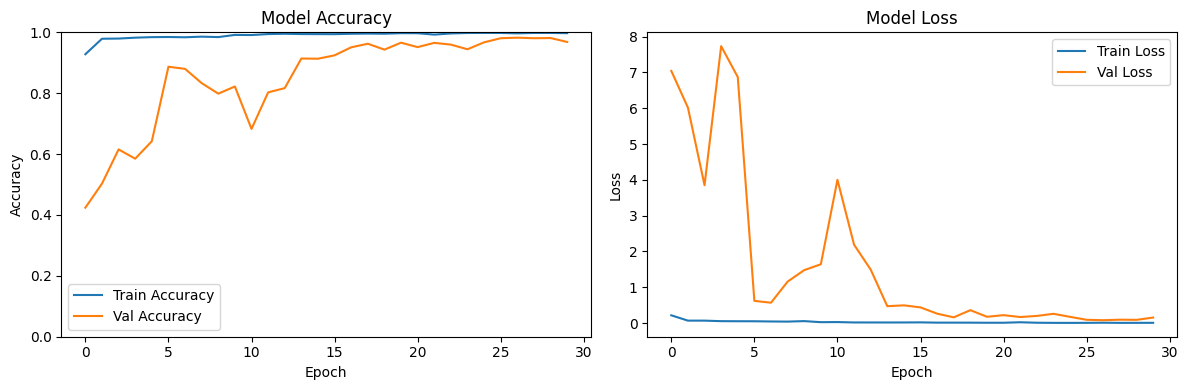

In [ ]:
# ==================================================
# CELL 11: PLOT TRAINING HISTORY
# ==================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


EVALUATION
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.9590 - loss: 0.5077

📈 Test Accuracy: 0.9590 (95.90%)
📈 Test Loss: 0.5077
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step

📋 Classification Report:
              precision    recall  f1-score   support

 Closed_Eyes       1.00      0.86      0.93       361
     No_yawn       0.99      0.99      0.99       469
   Open_Eyes       0.79      1.00      0.88       186
        Yawn       0.99      0.99      0.99       448

    accuracy                           0.96      1464
   macro avg       0.94      0.96      0.95      1464
weighted avg       0.97      0.96      0.96      1464



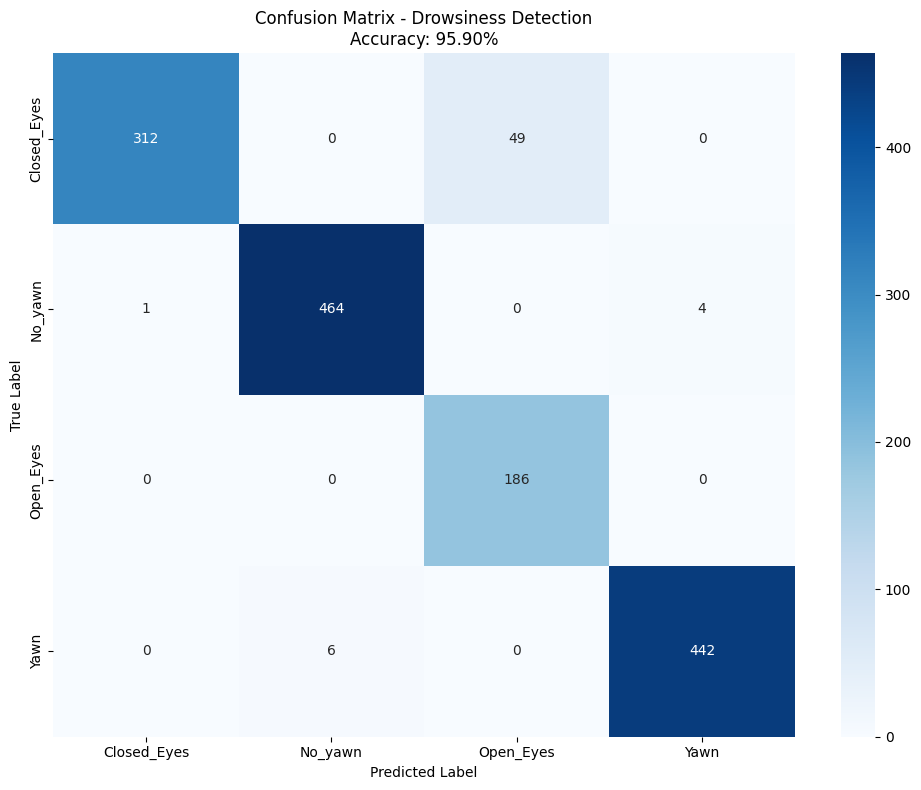

In [ ]:
# ==================================================
# CELL 12: EVALUASI TEST SET
# ==================================================
print("\n" + "="*60)
print("EVALUATION")
print("="*60)

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n📈 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"📈 Test Loss: {test_loss:.4f}")

# Predictions
test_predictions = model.predict(test_generator)
test_pred_classes = np.argmax(test_predictions, axis=1)
test_true_classes = test_generator.classes

# Classification Report
print(f"\n📋 Classification Report:")
print(classification_report(test_true_classes, test_pred_classes, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(test_true_classes, test_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix - Drowsiness Detection\nAccuracy: {test_acc:.2%}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
# ==================================================
# CELL 13: SAVE AS H5 + SAVEDMODEL
# ==================================================
print("\n" + "="*60)
print("SAVING MODEL")
print("="*60)

# Save as H5
model.save("drowsiness_model.h5")
print("✅ Saved: drowsiness_model.h5")

# Save as SavedModel (Folder)
model.export("drowsiness_saved_model")
print("✅ Saved: drowsiness_saved_model/")

# Download
from google.colab import files
files.download("drowsiness_model.h5")

# Zip SavedModel untuk download
!zip -r drowsiness_saved_model.zip drowsiness_saved_model/
files.download("drowsiness_saved_model.zip")

print("\n" + "="*60)
print("✅ SAVE COMPLETE!")
print("="*60)
print(f"\n📊 FINAL TEST ACCURACY: {test_acc:.2%}")
print("\n📁 FILE DOWNLOAD:")
print("   - drowsiness_model.h5")
print("   - drowsiness_saved_model.zip (extract di proyek)")


SAVING MODEL
✅ Saved: drowsiness_model.h5
Saved artifact at 'drowsiness_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140634511168656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140634511172304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140634511172688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140634511169424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140634511169616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140634511172496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140634511171536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140634511173648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140634511173264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140634511170768: TensorSpec(sha

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: drowsiness_saved_model/ (stored 0%)
  adding: drowsiness_saved_model/saved_model.pb (deflated 90%)
  adding: drowsiness_saved_model/variables/ (stored 0%)
  adding: drowsiness_saved_model/variables/variables.index (deflated 78%)
  adding: drowsiness_saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: drowsiness_saved_model/fingerprint.pb (stored 0%)
  adding: drowsiness_saved_model/assets/ (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ SAVE COMPLETE!

📊 FINAL TEST ACCURACY: 95.90%

📁 FILE DOWNLOAD:
   - drowsiness_model.h5
   - drowsiness_saved_model.zip (extract di proyek)


In [ ]:
# ==================================================
# CELL 14: TEST DENGAN GAMBAR DATASET
# ==================================================
print("\n" + "="*60)
print("TESTING WITH DATASET IMAGES")
print("="*60)

def test_single_image(image_path, expected_label):
    if not os.path.exists(image_path):
        print(f"   File not found: {image_path}")
        return

    img = cv2.imread(image_path)
    if img is None:
        print(f"   Cannot read {image_path}")
        return

    resized = cv2.resize(img, (128, 128))
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    normalized = rgb / 255.0
    input_tensor = np.expand_dims(normalized, axis=0)

    pred = model.predict(input_tensor, verbose=0)
    idx = np.argmax(pred[0])
    confidence = pred[0][idx]

    status = "✅" if CLASS_NAMES[idx] == expected_label else "❌"
    print(f"   {status} {os.path.basename(image_path)}: {CLASS_NAMES[idx]} ({confidence:.2%}) | Expected: {expected_label}")

print("\n📸 Testing with dataset images:")
for class_name in CLASS_NAMES:
    test_class_dir = os.path.join(BASE_PATH, 'Test', class_name)
    if os.path.exists(test_class_dir):
        images = [f for f in os.listdir(test_class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        if images:
            test_single_image(os.path.join(test_class_dir, images[0]), class_name)